# Data Loading

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [2]:
data = pd.read_csv(
    "market_data_processed.csv",
    parse_dates=True,
    index_col="Date"
)

In [3]:
data.head()

,Close_AAPL,Close_MSFT,Close_SPY,High_AAPL,High_MSFT,High_SPY,Low_AAPL,Low_MSFT,Low_SPY,Open_AAPL,Open_MSFT,Open_SPY,Volume_AAPL,Volume_MSFT,Volume_SPY,Log_Return_AAPL,Log_Return_MSFT,Log_Return_SPY
Date,,,,,,,,,,,,,,,,,,
2021-05-19,121.541817,233.826813,383.736237,121.766005,233.932609,383.913696,119.758019,229.479599,378.571312,120.050447,230.162451,380.056370,92612000.0,25739800.0,106467100.0,-0.001282,0.002471,-0.002625
2021-05-20,124.095665,237.058350,387.864471,124.495317,238.472160,389.125354,121.941464,234.538503,384.492806,122.068187,234.634687,384.614200,76857100.0,21800700.0,78022200.0,0.020794,0.013726,0.010701
2021-05-21,122.263161,235.798447,387.546844,124.768273,238.837660,390.591638,122.048714,235.384890,387.089202,124.592818,238.106716,389.349425,79295400.0,21863100.0,76578700.0,-0.014877,-0.005329,-0.000819
2021-05-24,123.890968,241.194031,391.497620,124.709764,241.559510,392.571694,122.760260,238.049021,389.545570,122.828492,238.318317,389.788415,63092900.0,21411500.0,51376700.0,0.013226,0.022624,0.010143
2021-05-25,123.696022,242.098083,390.629089,125.080175,243.088711,392.936029,123.130664,241.232492,390.050024,124.592792,242.146175,392.581111,72009500.0,17704300.0,57451400.0,-0.001575,0.003741,-0.002221


# Candlestick Charts

In [4]:
fig = go.Figure(data=[
    go.Candlestick(
        x=data.index,
        open=data["Open_AAPL"],
        high=data["High_AAPL"],
        low=data["Low_AAPL"],
        close=data["Close_AAPL"],
        name="AAPL"
    )
])

fig.update_layout(
    title="Apple Stock Price Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_dark"
)

fig.show()

# Moving Averages

In [5]:
data["SMA_50_AAPL"] = (
    data["Close_AAPL"]
    .rolling(window=50)
    .mean()
)

data["SMA_200_AAPL"] = (
    data["Close_AAPL"]
    .rolling(window=200)
    .mean()
)

In [6]:
fig = go.Figure()

# Closing Price Line
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Close_AAPL"],
        mode="lines",
        name="Close Price"
    )
)

# SMA 50
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["SMA_50_AAPL"],
        mode="lines",
        name="SMA 50"
    )
)

# SMA 200
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["SMA_200_AAPL"],
        mode="lines",
        name="SMA 200"
    )
)

fig.update_layout(
    title="Apple Stock Price with Moving Averages",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_dark"
)

fig.show()

# Bollinger Bands

In [7]:
data["Rolling_STD_AAPL"] = (
    data["Close_AAPL"]
    .rolling(window=20)
    .std()
)

data["BB_Upper_AAPL"] = (
    data["SMA_50_AAPL"] +
    2 * data["Rolling_STD_AAPL"]
)

data["BB_Lower_AAPL"] = (
    data["SMA_50_AAPL"] -
    2 * data["Rolling_STD_AAPL"]
)

In [8]:
fig = go.Figure()

# Close Price
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Close_AAPL"],
        mode="lines",
        name="Close Price"
    )
)

# SMA 50
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["SMA_50_AAPL"],
        mode="lines",
        name="SMA 50"
    )
)

# Upper Band
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["BB_Upper_AAPL"],
        mode="lines",
        name="Upper Band"
    )
)

# Lower Band
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["BB_Lower_AAPL"],
        mode="lines",
        name="Lower Band"
    )
)

fig.update_layout(
    title="Apple Bollinger Bands Analysis",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_dark"
)

fig.show()

# Seasonality Analysis

In [9]:
data["Daily_Return_AAPL"] = (
    data["Close_AAPL"]
    .pct_change() * 100
)

In [10]:
data["Month"] = data.index.month

In [11]:
monthly_returns = (
    data.groupby("Month")["Daily_Return_AAPL"]
    .mean()
)

In [12]:
import plotly.express as px

In [13]:
fig = px.bar(
    monthly_returns,
    title="Average Monthly Returns for Apple",
    labels={
        "value": "Average Return (%)",
        "Month": "Month"
    }
)

fig.update_layout(
    template="plotly_dark"
)

fig.show()

In [14]:
data["Day_Name"] = data.index.day_name()

In [15]:
weekday_returns = (
    data.groupby("Day_Name")["Daily_Return_AAPL"]
    .mean()
)

In [16]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

weekday_returns = weekday_returns.reindex(weekday_order)

In [17]:
fig = px.bar(
    weekday_returns,
    title="Average Weekday Returns for Apple",
    labels={
        "value": "Average Return (%)",
        "Day_Name": "Weekday"
    }
)

fig.update_layout(
    template="plotly_dark"
)

fig.show()

# Comparative Returns

In [18]:
for ticker in ["AAPL", "MSFT", "SPY"]:
    data[f"Daily_Return_{ticker}"] = (
        data[f"Close_{ticker}"]
        .pct_change()
    )

In [19]:
cumulative_returns = pd.DataFrame()

for ticker in ["AAPL", "MSFT", "SPY"]:
    cumulative_returns[ticker] = (
        (1 + data[f"Daily_Return_{ticker}"])
        .cumprod()
    )

In [20]:
fig = go.Figure()

for ticker in ["AAPL", "MSFT", "SPY"]:
    fig.add_trace(
        go.Scatter(
            x=cumulative_returns.index,
            y=cumulative_returns[ticker],
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Cumulative Returns Comparison",
    xaxis_title="Date",
    yaxis_title="Growth of $1 Investment",
    template="plotly_dark"
)

fig.show()

# Correlation Heatmap

In [21]:
returns_df = pd.DataFrame()

for ticker in ["AAPL", "MSFT", "SPY"]:
    returns_df[ticker] = data[f"Daily_Return_{ticker}"]

In [22]:
correlation_matrix = returns_df.corr()

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

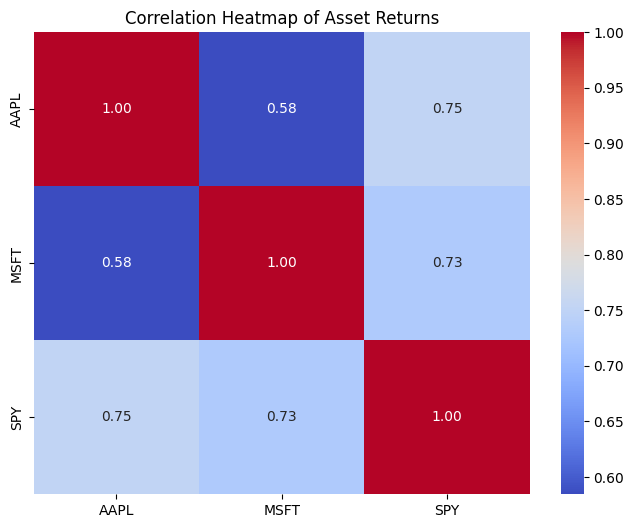

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Asset Returns")

plt.show()

# Rolling Volatility

In [25]:
data["Rolling_Volatility_AAPL"] = (
    data["Daily_Return_AAPL"]
    .rolling(window=30)
    .std()
)

In [26]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Rolling_Volatility_AAPL"],
        mode="lines",
        name="30-Day Rolling Volatility"
    )
)

fig.update_layout(
    title="Apple Rolling Volatility",
    xaxis_title="Date",
    yaxis_title="Volatility",
    template="plotly_dark"
)

fig.show()

# Return Distribution

In [27]:
fig = px.histogram(
    data,
    x="Daily_Return_AAPL",
    nbins=100,
    title="Distribution of Apple Daily Returns"
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Daily Return (%)",
    yaxis_title="Frequency"
)


fig.show()

In [28]:
print(data["Daily_Return_AAPL"].describe())

count    1251.000000
mean        0.000868
std         0.017312
min        -0.092456
25%        -0.007580
50%         0.001095
75%         0.009674
max         0.153289
Name: Daily_Return_AAPL, dtype: float64


# Risk Metrics & Drawdowns

In [35]:
tickers = ["AAPL", "MSFT", "SPY"]

# Ensure daily returns exist for all tickers
for ticker in tickers:
    data[f"Daily_Return_{ticker}"] = data[f"Close_{ticker}"].pct_change()

# Create cumulative return dataframe
cumulative_returns = pd.DataFrame(index=data.index)

for ticker in tickers:
    cumulative_returns[ticker] = (1 + data[f"Daily_Return_{ticker}"]).cumprod()

In [44]:
data = data.dropna(subset=[f"Daily_Return_{ticker}" for ticker in tickers])

In [45]:
running_peak = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_peak) / running_peak

In [46]:
drawdown.head()

,AAPL,MSFT,SPY
Date,,,
2021-05-19,NaN,NaN,NaN
2021-05-20,0.000000,0.000000,0.000000
2021-05-21,-0.014767,-0.005315,-0.000819
2021-05-24,-0.001650,0.000000,0.000000
2021-05-25,-0.003220,0.000000,-0.002218


In [41]:
fig = go.Figure()

for ticker in tickers:
    fig.add_trace(
        go.Scatter(
            x=drawdown.index,
            y=drawdown[ticker],
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Drawdown Analysis Across Assets",
    xaxis_title="Date",
    yaxis_title="Drawdown",
    template="plotly_dark"
)

fig.show()

In [42]:
max_drawdown = drawdown.min()

max_drawdown

,0
AAPL,-0.333605
MSFT,-0.371485
SPY,-0.244964


In [43]:
max_drawdown_percent = max_drawdown * 100

max_drawdown_percent

,0
AAPL,-33.360514
MSFT,-37.148473
SPY,-24.496391


In [48]:
max_drawdown_table = pd.DataFrame({
    "Max Drawdown (%)": max_drawdown_percent.round(2)
})

max_drawdown_table

,Max Drawdown (%)
AAPL,-33.36
MSFT,-37.15
SPY,-24.50


In [49]:
tickers = ["AAPL", "MSFT", "SPY"]

returns_df = pd.DataFrame(index=data.index)

for ticker in tickers:
    returns_df[ticker] = data[f"Daily_Return_{ticker}"]

returns_df = returns_df.dropna()

In [50]:
annualized_return = returns_df.mean() * 252

In [51]:
annualized_volatility = returns_df.std() * (252 ** 0.5)

In [52]:
sharpe_ratio = annualized_return / annualized_volatility

In [53]:
risk_metrics = pd.DataFrame({
    "Annualized Return (%)": annualized_return * 100,
    "Annualized Volatility (%)": annualized_volatility * 100,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown (%)": max_drawdown_percent
})

risk_metrics = risk_metrics.round(2)

risk_metrics

,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
AAPL,21.89,27.48,0.80,-33.36
MSFT,14.55,26.37,0.55,-37.15
SPY,14.75,17.07,0.86,-24.50


In [54]:
# Save processed dataset with EDA features
data.to_csv("market_data_eda_features.csv")

# Save cumulative returns
cumulative_returns.to_csv("cumulative_returns.csv")

# Save drawdown data
drawdown.to_csv("drawdown_data.csv")

# Save risk metrics table
risk_metrics.to_csv("risk_metrics.csv")

# Save correlation matrix
correlation_matrix.to_csv("correlation_matrix.csv")

In [56]:
from google.colab import files

files.download("market_data_eda_features.csv")
files.download("cumulative_returns.csv")
files.download("drawdown_data.csv")
files.download("risk_metrics.csv")
files.download("correlation_matrix.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>